# 01 · Data preparation and EDA

## 0. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42 

# Folder paths (this notebook lives inside the notebooks/ folder)
RAW_FILE = "../data/online_shoppers_intention.csv"
DATA_DIR = "../data"

# The 8 behavioral columns we will cluster on later
BEHAVIOR_COLS = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates",
]

## 1. Load the data

In [5]:
df = pd.read_csv(RAW_FILE)

print("Shape:", df.shape)
df.head()

Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

## 2. Self-checks against the documentation

In [8]:
print("Rows, columns:", df.shape)                 
print("Missing values:", df.isna().sum().sum())    
print()
print(df["Revenue"].value_counts())               
print()
print(df["VisitorType"].value_counts())            

Rows, columns: (12330, 18)
Missing values: 0

Revenue
False    10422
True      1908
Name: count, dtype: int64

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64


In [9]:
df["Month"].value_counts()

Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

## 3. Exact duplicate rows

In [11]:
n_duplicates = df.duplicated().sum()
print("Duplicate rows (extra copies):", n_duplicates)

Duplicate rows (extra copies): 125


In [12]:
# What do the duplicated rows look like?
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows[BEHAVIOR_COLS + ["Revenue"]].value_counts()

Administrative  Administrative_Duration  Informational  Informational_Duration  ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  Revenue
0               0.0                      0              0.0                     1               0.0                      0.2          0.2        False      189
                                                                                2               0.0                      0.2          0.2        False       12
Name: count, dtype: int64

In [13]:
DROP_DUPLICATES = False   # decision: keep duplicates

if DROP_DUPLICATES:
    df = df.drop_duplicates().reset_index(drop=True)

print("Rows kept:", len(df))

Rows kept: 12330


## 4. Odd records

In [15]:
# Helper columns for these checks
total_pages = df["Administrative"] + df["Informational"] + df["ProductRelated"]
total_duration = df["Administrative_Duration"] + df["Informational_Duration"] + df["ProductRelated_Duration"]

In [16]:
# Check 1: zero pages but some time spent (should be impossible)
print("Admin:   0 pages but time > 0 ->", ((df["Administrative"] == 0) & (df["Administrative_Duration"] > 0)).sum())
print("Info:    0 pages but time > 0 ->", ((df["Informational"] == 0) & (df["Informational_Duration"] > 0)).sum())
print("Product: 0 pages but time > 0 ->", ((df["ProductRelated"] == 0) & (df["ProductRelated_Duration"] > 0)).sum())

Admin:   0 pages but time > 0 -> 0
Info:    0 pages but time > 0 -> 0
Product: 0 pages but time > 0 -> 0


In [17]:
# Check 2: some pages but zero time
print("Admin:   pages > 0 but time = 0 ->", ((df["Administrative"] > 0) & (df["Administrative_Duration"] == 0)).sum())
print("Info:    pages > 0 but time = 0 ->", ((df["Informational"] > 0) & (df["Informational_Duration"] == 0)).sum())
print("Product: pages > 0 but time = 0 ->", ((df["ProductRelated"] > 0) & (df["ProductRelated_Duration"] == 0)).sum())

Admin:   pages > 0 but time = 0 -> 135
Info:    pages > 0 but time = 0 -> 226
Product: pages > 0 but time = 0 -> 717


In [18]:
# Check 3: other odd cases
print("Sessions with 0 total pages:     ", (total_pages == 0).sum())
print("Sessions with 0 total duration:  ", (total_duration == 0).sum())
print("Sessions longer than 3 hours:    ", (total_duration > 3 * 3600).sum())
print("Sessions longer than 8 hours:    ", (total_duration > 8 * 3600).sum())
print("Longest session (hours):         ", round(total_duration.max() / 3600, 1))

Sessions with 0 total pages:      6
Sessions with 0 total duration:   720
Sessions longer than 3 hours:     78
Sessions longer than 8 hours:     3
Longest session (hours):          19.4


In [19]:
# Check 4: the very long sessions
df[total_duration > 8 * 3600][["ProductRelated", "ProductRelated_Duration", "Revenue"]]

,ProductRelated,ProductRelated_Duration,Revenue
5152,705,43171.23338,False
8071,449,63973.52223,False
9238,343,29970.46597,False


In [20]:
# Check 5: Bounce and Exit rates both stop at exactly 0.2
print("Max BounceRates:", df["BounceRates"].max())
print("Max ExitRates:  ", df["ExitRates"].max())

at_cap = (df["BounceRates"] == 0.2) & (df["ExitRates"] == 0.2)
print("Sessions with both = 0.2:", at_cap.sum())
print("Their conversion rate:   ", round(df.loc[at_cap, "Revenue"].mean(), 4))

Max BounceRates: 0.2
Max ExitRates:   0.2
Sessions with both = 0.2: 700
Their conversion rate:    0.0043


## 5. Summary statistics

In [22]:
df[BEHAVIOR_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.32,3.32,0.0,0.00,1.00,4.00,27.00
Administrative_Duration,12330.0,80.82,176.78,0.0,0.00,7.50,93.26,3398.75
Informational,12330.0,0.50,1.27,0.0,0.00,0.00,0.00,24.00
Informational_Duration,12330.0,34.47,140.75,0.0,0.00,0.00,0.00,2549.38
ProductRelated,12330.0,31.73,44.48,0.0,7.00,18.00,38.00,705.00
ProductRelated_Duration,12330.0,1194.75,1913.67,0.0,184.14,598.94,1464.16,63973.52
BounceRates,12330.0,0.02,0.05,0.0,0.00,0.00,0.02,0.20
ExitRates,12330.0,0.04,0.05,0.0,0.01,0.03,0.05,0.20


In [23]:
# Share of zeros in each column
(df[BEHAVIOR_COLS] == 0).mean().round(3)

Administrative             0.468
Administrative_Duration    0.479
Informational              0.787
Informational_Duration     0.805
ProductRelated             0.003
ProductRelated_Duration    0.061
BounceRates                0.448
ExitRates                  0.006
dtype: float64

## 6. Distributions

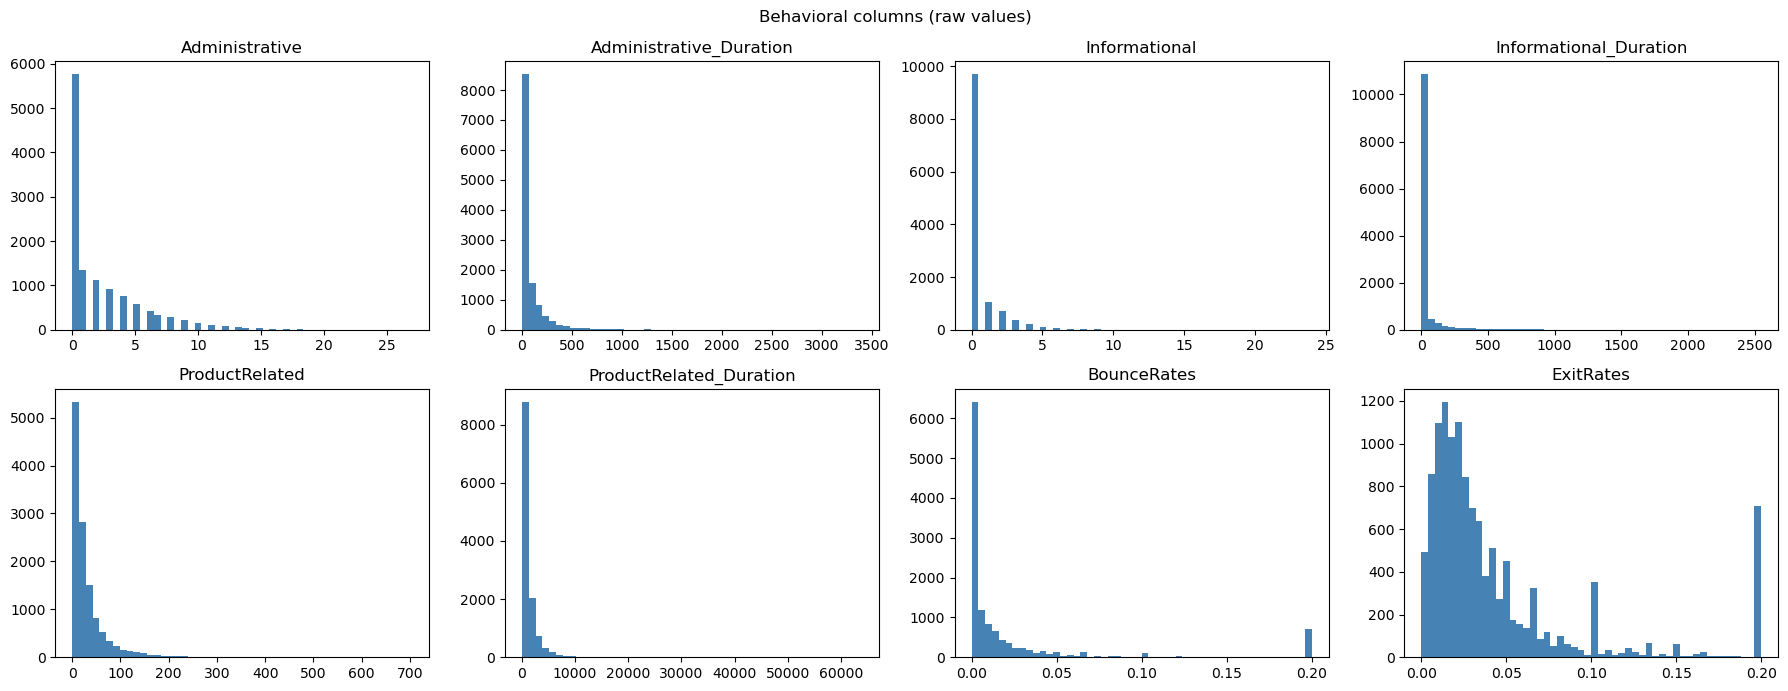

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(BEHAVIOR_COLS):
    axes[i].hist(df[col], bins=50, color="steelblue")
    axes[i].set_title(col)

plt.suptitle("Behavioral columns (raw values)")
plt.tight_layout()
plt.show()

## 7. Correlation heatmap

*Pearson* correlation measures straight-line relationships and is pulled around by extreme values.
*Spearman* compares only the **rank order**, so it handles skewed data better. We show both.

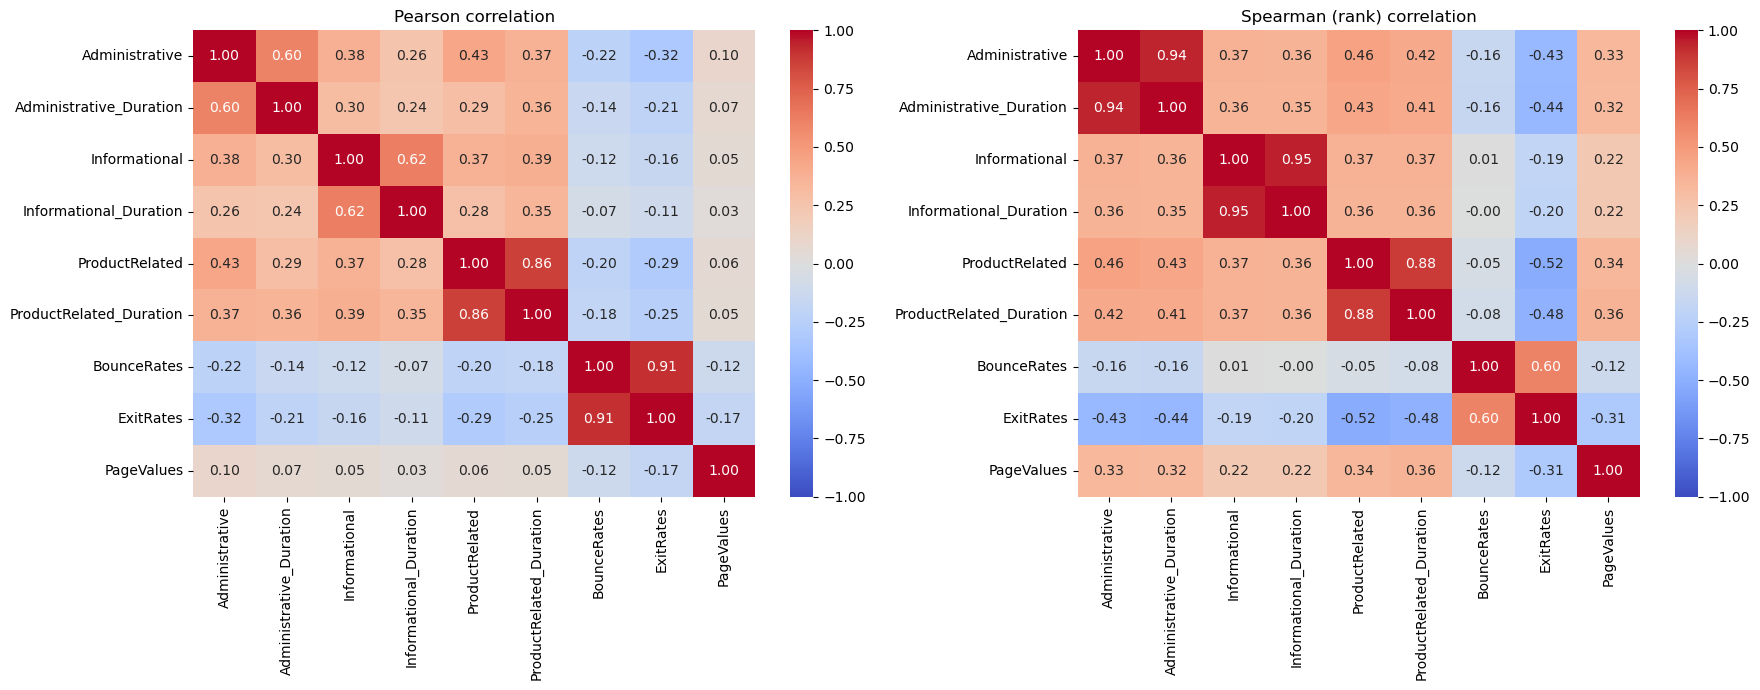

In [27]:
corr_cols = BEHAVIOR_COLS + ["PageValues"]   # PageValues shown for reference only

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(df[corr_cols].corr(method="pearson"), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson correlation")

sns.heatmap(df[corr_cols].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman (rank) correlation")

plt.tight_layout()
plt.show()

In [28]:
pearson = df["BounceRates"].corr(df["ExitRates"], method="pearson")
spearman = df["BounceRates"].corr(df["ExitRates"], method="spearman")
print("BounceRates vs ExitRates")
print("  Pearson: ", round(pearson, 3))
print("  Spearman:", round(spearman, 3))

BounceRates vs ExitRates
  Pearson:  0.913
  Spearman: 0.602


## 8. Overall conversion rate

In [30]:
conversion_rate = df["Revenue"].mean()
print(f"Overall conversion rate: {conversion_rate:.2%}  ({df['Revenue'].sum()} of {len(df)} sessions)")

Overall conversion rate: 15.47%  (1908 of 12330 sessions)


## 9. Save clean data

In [32]:
df.to_csv(f"{DATA_DIR}/sessions_clean.csv", index=False)